<a href="https://colab.research.google.com/github/tinemyumi/saude-mental-datasus/blob/main/notebooks/4.eda_panorama.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **EDA: Panorama Geral**

## **Objetivo**
Descrever a estrutura e a qualidade do dataset de internações em saúde mental (SIH/SUS - SP, 2015–2025),
gerando uma visão consolidada das variáveis principais e a **Tabela 1** para publicação.

## **Conteúdo**
- 1. Setup
- 2. Carregamento dos Dados
- 3. Qualidade dos Dados
  - 3.1 Valores Nulos
  - 3.2 Valores Duplicados
  - 3.3 Consistências
- 4. Volume Geral
- 5. Cobertura Geográfica
- 6. Distribuição das Variáveis-Chave
- 7. Tabela 1: Características Gerais por Período

## **Histórico de Alterações**
- **Data:** 06.02.2026 | **Autor:** Larissa Tinem


## **1. Setup**

In [63]:
# Bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [64]:
# Paleta e estilo
COLOR1 = '#1B4F72'   # azul escuro
COLOR2 = '#48C9B0'   # verde-azulado
COLOR3 = '#5499C7'   # azul médio
COLORS = [COLOR1, COLOR2, COLOR3]
PALETTE_PERIODO = {
    'Pre-Pandemia' : COLOR1,
    'Pandemia'     : COLOR2,
    'Pos-Pandemia' : COLOR3,
}

plt.rcParams['figure.dpi']      = 120
plt.rcParams['axes.spines.top']  = False
plt.rcParams['axes.spines.right']= False
sns.set_style('whitegrid')

# Ordem canônica dos períodos
ORDEM_PERIODOS = ['Pre-Pandemia', 'Pandemia', 'Pos-Pandemia']

## **2. Carregamento dos Dados**

In [65]:
# Carregar os arquivos
df_pre = pd.read_parquet('/content/drive/MyDrive/Dataframes/df_sih_sus_sem_tratamento/saude_mental_pre_pandemia.parquet')
df_pan = pd.read_parquet('/content/drive/MyDrive/Dataframes/df_sih_sus_sem_tratamento/saude_mental_pandemia.parquet')
df_pos = pd.read_parquet('/content/drive/MyDrive/Dataframes/df_sih_sus_sem_tratamento/saude_mental_pos_pandemia.parquet')

# Criar a coluna de período para facilitar a comparação posterior
df_pre['periodo'] = 'Pre-Pandemia'
df_pan['periodo'] = 'Pandemia'
df_pos['periodo'] = 'Pos-Pandemia'

# Unir tudo em um único DataFrame
df = pd.concat([df_pre, df_pan, df_pos], ignore_index=True)

del df_pre, df_pan, df_pos

## **3. Qualidade dos Dados**

### **3.1. Valores Nulos**

In [66]:
df.isnull().sum()

,0
UF_ZI,0
ANO_CMPT,0
MES_CMPT,0
NASC,0
IDADE,0
SEXO,0
RACA_COR,0
ESPEC,0
IDENT,0
MUNIC_RES,0


### **3.2. Valores duplicados**

**Análise Inicial**

- **Quantidade total de linhas:** 1.079.670
- **Quantidade total de internações:** 1.061.744
- **Diferença:** 17.926

A base apresentou aproximadamente 1,7% de registros duplicados, associados a reprocessamentos administrativos, os quais foram removidos para evitar superestimação do número de internações.



In [67]:
df.duplicated().sum()

np.int64(450)

In [68]:
# Identificando ~evento~ de uma internação
chave_internacao = [
    'UF_ZI',
    'ANO_CMPT',
    'MUNIC_RES',
    'DT_INTER',
    'DT_SAIDA',
    'DIAG_PRINC',
    'SEXO',
    'IDADE',
    'MORTE'
]

# Elimina duplicatas de acordo com o evento de internação
df_tratado = df.drop_duplicates(subset=chave_internacao)

# Conta o total de internações
total_internacoes = df_tratado.shape[0]
print('Número total de linhas: ', df.shape[0])
print('Número total de internações: ', total_internacoes)
print('Diferença: ', df.shape[0] - df_tratado.shape[0])

Número total de linhas:  1079670
Número total de internações:  1061744
Diferença:  17926


**Interpretação:** queda esperada ao longo dos anos indica melhora no preenchimento, o que impacta a análise de raça: documentar na seção de limitações do artigo.

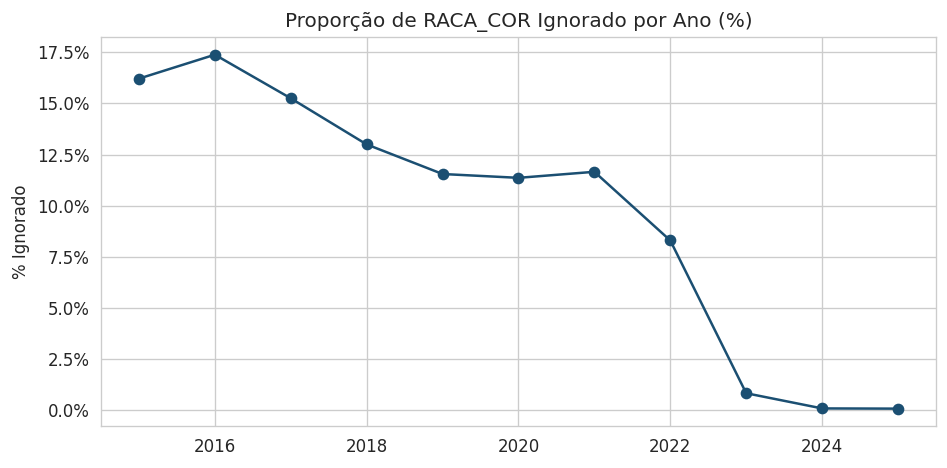

In [69]:
# Evolução anual do preenchimento de RACA_COR
# Importante para a discussão metodológica do artigo
raca_ignorado = (
    df.assign(ignorado=df['RACA_COR'] == '99')
    .groupby('ANO_CMPT')['ignorado']
    .mean() * 100
)

fig, ax = plt.subplots(figsize=(8, 4))
raca_ignorado.plot(ax=ax, marker='o', color=COLOR1)
ax.set_title('Proporção de RACA_COR Ignorado por Ano (%)')
ax.set_ylabel('% Ignorado')
ax.set_xlabel('')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
plt.tight_layout()
plt.show()


### **3.3 Consistência**

In [70]:
# Verifica valores inesperados nas variáveis categóricas principais
checks = {
    'SEXO'   : ['1', '3'],
    'CAR_INT': ['01', '02'],
    'MORTE'  : ['0', '1'],
    'COMPLEX': ['01', '02', '03'],
}

for col, valores_esperados in checks.items():
    valores_encontrados = df[col].unique().tolist()
    inesperados = [v for v in valores_encontrados if v not in valores_esperados]
    status = '✅' if not inesperados else f'⚠️  {inesperados}'
    print(f'{col:10s} | esperado: {valores_esperados} | {status}')

SEXO       | esperado: ['1', '3'] | ✅
CAR_INT    | esperado: ['01', '02'] | ✅
MORTE      | esperado: ['0', '1'] | ✅
COMPLEX    | esperado: ['01', '02', '03'] | ✅


In [71]:
# Verifica consistência de datas e idade
print(f'Período coberto    : {df["ANO_CMPT"].min()} – {df["ANO_CMPT"].max()}')
print(f'Idades negativas   : {(df["IDADE"] < 0).sum()}')
print(f'Idades > 120       : {(df["IDADE"] > 120).sum()}')
print(f'DT_SAIDA < DT_INTER: {(df["DT_SAIDA"] < df["DT_INTER"]).sum()}')
print(f'DIAS_PERM < 0      : {(df["DIAS_PERM"] < 0).sum()}')

Período coberto    : 2015 – 2025
Idades negativas   : 0
Idades > 120       : 0
DT_SAIDA < DT_INTER: 0
DIAS_PERM < 0      : 0


## **4. Volume Geral**

**Análise Inicial**


In [84]:
df['periodo'] = pd.Categorical(
    df['periodo'],
    categories=['Pre-Pandemia','Pandemia','Pos-Pandemia'],
    ordered=True
)

**Análise Inicial:**

Os dados revelam que o período Pre-Pandemia concentrou a maior parte da atividade hospitalar, respondendo por 51,5% do total de internações da série histórica analisada. Durante a Pandemia, houve uma queda acentuada para 22,3% do volume total , evidenciando uma forte retração no acesso ou na oferta de serviços de saúde mental. No Pos-Pandemia, observa-se uma recuperação parcial com 26,1% das internações , mas o volume permanece significativamente inferior ao patamar original, o que reforça a existência de uma demanda reprimida e uma retomada ainda incompleta do sistema.

In [85]:
# Internações por período
vol = df.groupby('periodo', observed=True).size().reset_index(name='internacoes')
vol['pct_total'] = (vol['internacoes'] / vol['internacoes'].sum() * 100).round(1)
print(vol.to_string(index=False))

     periodo  internacoes  pct_total
Pre-Pandemia       556336       51.5
    Pandemia       241285       22.3
Pos-Pandemia       282049       26.1


**Análise Inicial:**

Os dados indicam que o sistema de saúde mental sofreu uma retração severa: a média mensal de internações, que era de 9.272 no pré-pandemia, caiu para 6.702 durante a crise sanitária. Embora o período pós-pandemia apresente uma recuperação parcial para 7.834, o volume de atendimentos ainda permanece consideravelmente abaixo dos níveis de 2019.

Um ponto relevante é a redução drástica no desvio padrão (std), que sugere que o sistema perdeu sua capacidade de oscilação e tornou-se mais "engessado". Essa baixa variabilidade indica que os hospitais podem estar operando no limite de uma capacidade reduzida, com pouca margem para absorver flutuações ou novos picos de demanda reprimida.

In [86]:
# Média mensal por período
media_mensal = (
    df.groupby(['periodo', 'ANO_CMPT', 'MES_CMPT'], observed=True)
    .size()
    .reset_index(name='total_mes')
    .groupby('periodo', observed=True)['total_mes']
    .agg(['mean', 'std', 'median'])
    .round(1)
)
print(media_mensal)

                mean     std  median
periodo                             
Pre-Pandemia  9272.3  1337.7  8657.0
Pandemia      6702.4   589.0  6660.5
Pos-Pandemia  7834.7   358.8  7799.0


**Análise Inicial:**

Os dados de variação percentual confirmam a profundidade do impacto da pandemia na rede de saúde mental de São Paulo:

- **Choque Inicial:** Houve uma queda brusca de 27,7% no volume médio de internações durante a pandemia em comparação ao período anterior.
- **Recuperação Gradual:** O período pós-pandemia apresenta uma retomada de 16,9% em relação ao auge da crise sanitária, indicando que os serviços estão sendo restabelecidos.
- **Déficit Persistente:** Apesar da melhora recente, o sistema ainda opera com um déficit de 15,5% comparado ao patamar pré-pandemia.

In [87]:
# Variação percentual entre períodos
medias = media_mensal['mean']
print(f'Pré → Pandemia   : {(medias["Pandemia"] / medias["Pre-Pandemia"] - 1) * 100:.1f}%')
print(f'Pandemia → Pós   : {(medias["Pos-Pandemia"] / medias["Pandemia"] - 1) * 100:.1f}%')
print(f'Pré → Pós        : {(medias["Pos-Pandemia"] / medias["Pre-Pandemia"] - 1) * 100:.1f}%')

Pré → Pandemia   : -27.7%
Pandemia → Pós   : 16.9%
Pré → Pós        : -15.5%


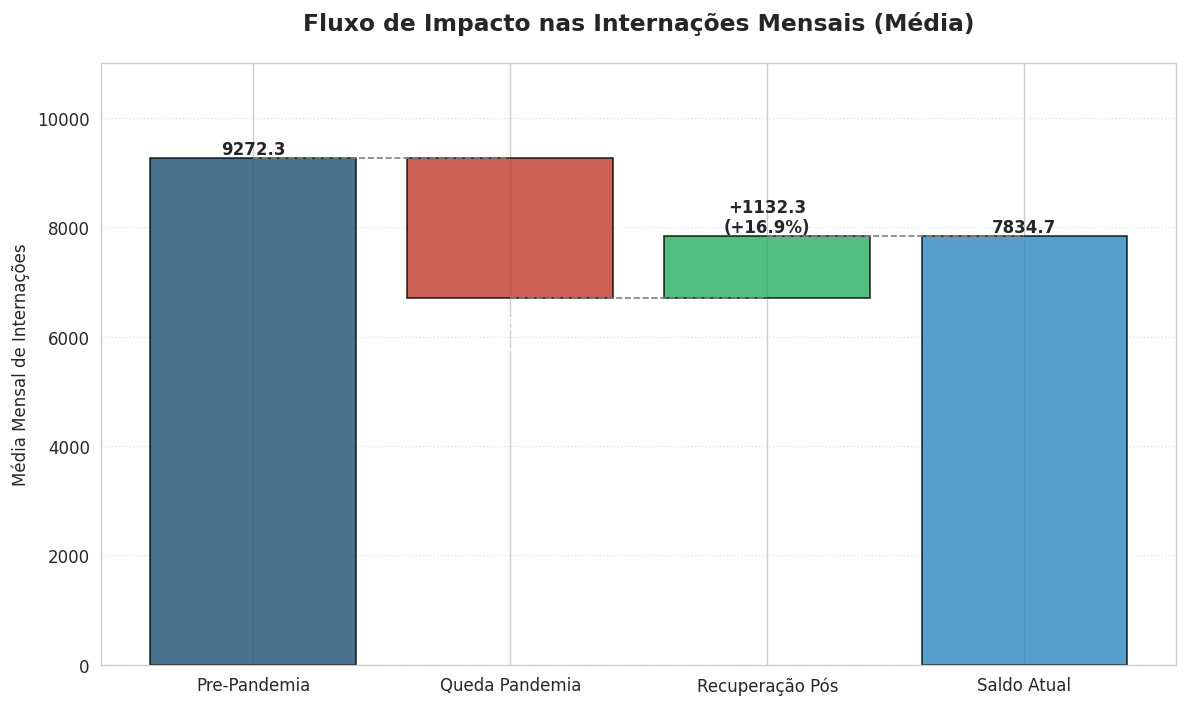

In [98]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Definir os valores baseados na sua análise
# Média inicial, a queda (negativa), a subida (positiva) e o valor final
labels = ['Pre-Pandemia', 'Queda Pandemia', 'Recuperação Pós', 'Saldo Atual']
values = [9272.3, -2569.9, 1132.3, 7834.7]

# 2. Calcular a base (bottom) de cada barra para dar o efeito de escada
# O 'cumulative' soma os valores passo a passo para saber onde a próxima barra começa
cumulative = np.cumsum([0] + values[:-1])
bottom = cumulative.copy()

# As barras de "Início" e "Saldo Atual" devem sair do chão (zero)
bottom[0] = 0
bottom[-1] = 0

# 3. Definir cores: Azul (totais), Vermelho (queda), Verde (recuperação)
colors = ['#1B4F72', '#C0392B', '#27AE60', '#2E86C1']

plt.figure(figsize=(10, 6))

# 4. Gerar o gráfico de barras
bars = plt.bar(labels, values, bottom=bottom, color=colors, edgecolor='black', alpha=0.8)

# 5. Adicionar as linhas conectoras entre as barras
for i in range(len(labels) - 1):
    plt.plot([i, i+1], [cumulative[i+1], cumulative[i+1]], color='gray', linestyle='--', linewidth=1)

# 6. Adicionar os rótulos de texto e porcentagens
for i, bar in enumerate(bars):
    height = bar.get_height()
    y_pos = bar.get_y() + height

    if i == 1: # Texto para a Queda
        txt = f'{values[i]:.1f}\n(-27.7%)'
        plt.text(bar.get_x() + bar.get_width()/2, y_pos - 300, txt, ha='center', va='top', fontweight='bold', color='white')
    elif i == 2: # Texto para a Recuperação
        txt = f'+{values[i]:.1f}\n(+16.9%)'
        plt.text(bar.get_x() + bar.get_width()/2, y_pos, txt, ha='center', va='bottom', fontweight='bold')
    else: # Texto para os Totais (Pre e Saldo)
        plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:.1f}', ha='center', va='bottom', fontweight='bold')

# Ajustes finais de layout
plt.title('Fluxo de Impacto nas Internações Mensais (Média)', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Média Mensal de Internações')
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.ylim(0, 11000)

plt.tight_layout()
plt.show()

**Análise Inicial:**

Os dados mostram que a rede de saúde mental em São Paulo sofreu um baque estrutural do qual ainda tenta se recuperar. O volume médio de internações mensais, que girava em torno de 9.272 antes da crise, despencou 27,7%, chegando a 6.702 atendimentos durante a pandemia.

Embora o cenário tenha melhorado no pós-pandemia, subindo para 7.835, o sistema ainda opera com um déficit de 15,5% comparado ao que víamos em 2019. O ponto mais preocupante é que a variação entre os meses (o desvio padrão) também caiu drasticamente, o que sugere um sistema mais "engessado". Essa falta de oscilação indica que os hospitais podem estar trabalhando no limite de uma capacidade reduzida, dificultando a absorção de toda a demanda que ficou represada nos últimos anos.

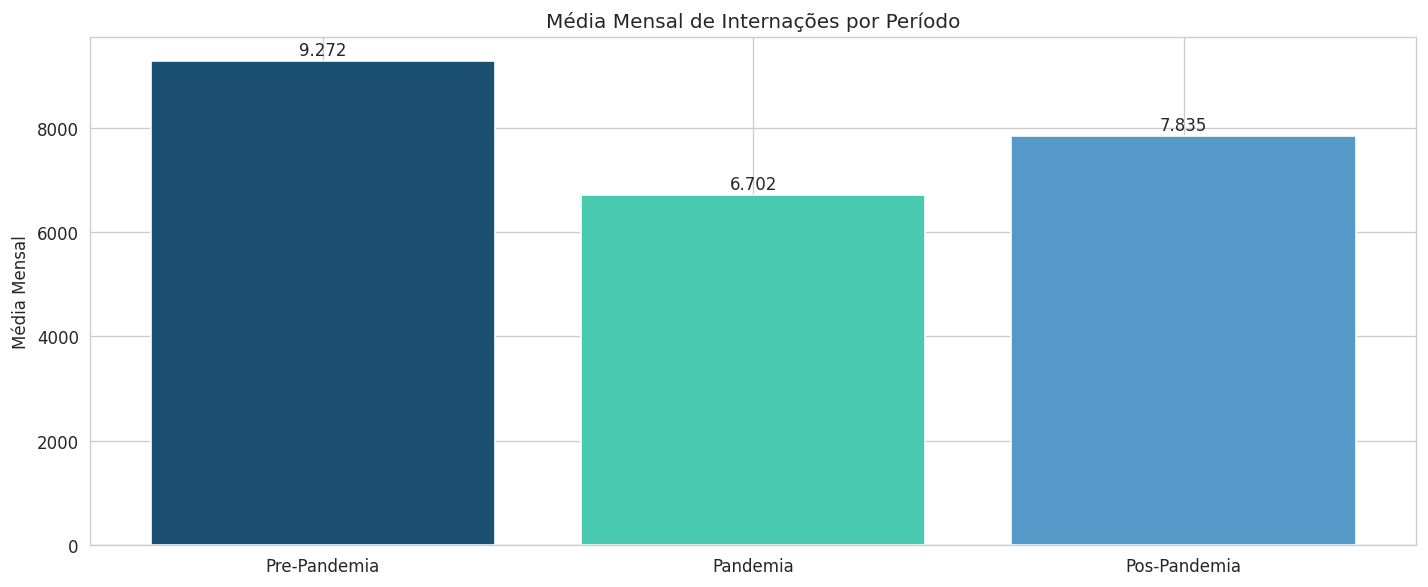

In [88]:
ordem = ['Pre-Pandemia', 'Pandemia', 'Pos-Pandemia']
media_mensal = media_mensal.reindex(ordem)

fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(
    media_mensal.index,
    media_mensal['mean'],
    color=[PALETTE_PERIODO.get(p, '#999999') for p in media_mensal.index],
    edgecolor='white'
)

for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + 50,
        f'{h:,.0f}'.replace(',', '.'),
        ha='center',
        va='bottom',
        fontsize=10
    )

ax.set_title('Média Mensal de Internações por Período')
ax.set_ylabel('Média Mensal')

plt.tight_layout()
plt.show()

## **6. Cobertura Geográfica**

**Análise Inicial**

Há 1.256 municípios de residência, mas apenas 332 concentram as internações.
Isso indica forte centralização da oferta hospitalar em um número reduzido de cidades.
Muitos municípios dependem de deslocamento para atendimento.
O dado sugere possível desigualdade regional no acesso aos serviços.
Vale analisar fluxo de evasão para identificar polos sobrecarregados.

In [99]:
# Municípios de residência vs. de internação
n_munic_res = df['MUNIC_RES'].nunique()
n_munic_int = df['MUNIC_MOV'].nunique()

print(f'Municípios de residência : {n_munic_res}')
print(f'Municípios de internação : {n_munic_int}')
print(f'Razão res/int            : {n_munic_res / n_munic_int:.1f}x')
print('\nInterpretação: cada município que interna atende em média '
      f'{n_munic_res / n_munic_int:.1f} municípios de origem.')

Municípios de residência : 1256
Municípios de internação : 332
Razão res/int            : 3.8x

Interpretação: cada município que interna atende em média 3.8 municípios de origem.


In [100]:
# Municípios com zero internações (vazios assistenciais absolutos)
munic_com_internacao = set(df['MUNIC_MOV'].unique())
munic_com_residentes = set(df['MUNIC_RES'].unique())

vazios_absolutos = munic_com_residentes - munic_com_internacao
print(f'Municípios que geram pacientes mas não internam: {len(vazios_absolutos)}')
print(f'({len(vazios_absolutos)/len(munic_com_residentes)*100:.1f}% dos municípios de residência)')

Municípios que geram pacientes mas não internam: 924
(73.6% dos municípios de residência)


## **7. Distribuição das Variáveis-Chave**

**Análise Inicial:**

O perfil das internações é concentrado em adultos jovens e de meia-idade, com um pico evidente na faixa dos 30 aos 50 anos. No gráfico de permanência, chama a atenção o acúmulo massivo de casos que duram exatamente 30 dias, o que sugere um padrão administrativo ou um teto de faturamento do sistema, em vez de uma distribuição puramente clínica. Fora esse pico, a maioria das altas ocorre rapidamente nos primeiros dias, mostrando que o sistema lida com um grande volume de internações de curta duração antes de estabilizar.

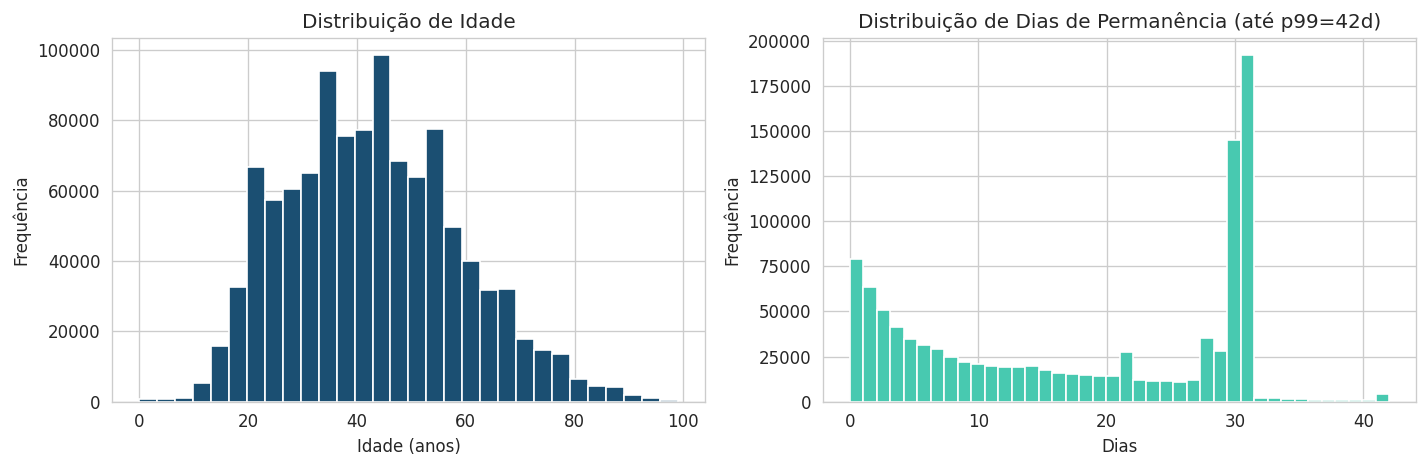

           IDADE  DIAS_PERM
count  1079670.0  1079670.0
mean        43.0       18.0
std         15.9       12.1
min          0.0        0.0
25%         31.0        6.0
50%         42.0       18.0
75%         54.0       30.0
max         99.0      261.0


In [92]:
# Painel com distribuição das principais variáveis numéricas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Idade
axes[0].hist(df['IDADE'], bins=30, color=COLOR1, edgecolor='white')
axes[0].set_title('Distribuição de Idade')
axes[0].set_xlabel('Idade (anos)')
axes[0].set_ylabel('Frequência')

# Tempo de permanência (limitado ao percentil 99 para não distorcer)
p99 = df['DIAS_PERM'].quantile(0.99)
axes[1].hist(df[df['DIAS_PERM'] <= p99]['DIAS_PERM'],
             bins=40, color=COLOR2, edgecolor='white')
axes[1].set_title(f'Distribuição de Dias de Permanência (até p99={p99:.0f}d)')
axes[1].set_xlabel('Dias')
axes[1].set_ylabel('Frequência')

plt.tight_layout()
plt.show()

print(df[['IDADE', 'DIAS_PERM']].describe().round(1))

**Análise Inicial:**

A taxa de óbito hospitalar para internações de saúde mental em São Paulo é historicamente baixa, com uma média geral de 0,29%. Durante a pandemia, esse indicador permaneceu praticamente estável em 0,30%, o que sugere que o desfecho de óbito não foi o principal impacto direto da crise nesse setor assistencial. No período pós-pandemia, nota-se uma leve oscilação para baixo, atingindo 0,27%, mantendo o padrão de que a mortalidade dentro das unidades de internação psiquiátrica é um evento raro e estruturalmente controlado no estado.

In [101]:
# Taxa de óbitos geral e por período
df['morte_flag'] = df['MORTE'].astype(str) == '1'

obito_geral = df['morte_flag'].mean() * 100
obito_periodo = df.groupby('periodo', observed=True)['morte_flag'].mean() * 100

print(f'Taxa de óbito geral: {obito_geral:.2f}%')
print('Taxa de óbito por período:')
print(obito_periodo.round(2))

Taxa de óbito geral: 0.29%
Taxa de óbito por período:
periodo
Pre-Pandemia    0.29
Pandemia        0.30
Pos-Pandemia    0.27
Name: morte_flag, dtype: float64


## **8. Tabela 1 — Características Gerais por Período**

Tabela-resumo no formato padrão de publicações epidemiológicas.
Pode ser exportada diretamente para o artigo.

In [95]:
# Decodificações necessárias para a Tabela 1
df['SEXO_DESC']    = df['SEXO'].map({'1': 'Masculino', '3': 'Feminino'})
df['RACA_DESC']    = df['RACA_COR'].map({
    '01': 'Branca', '02': 'Parda', '03': 'Preta',
    '04': 'Amarela', '05': 'Indígena', '99': 'Ignorado'
})
df['CAR_INT_DESC']  = df['CAR_INT'].map({'01': 'Eletivo', '02': 'Urgência'})
df['evasao']        = df['MUNIC_RES'] != df['MUNIC_MOV']

In [96]:
def tabela1(grupo):
    return pd.Series({
        'N internações'             : len(grupo),
        'Média mensal'              : round(len(grupo) / grupo['ANO_CMPT'].nunique() / 12, 0),
        'Idade — média (dp)'        : f'{grupo["IDADE"].mean():.1f} ({grupo["IDADE"].std():.1f})',
        'Idade — mediana'           : grupo['IDADE'].median(),
        '% Feminino'               : f'{(grupo["SEXO_DESC"] == "Feminino").mean()*100:.1f}%',
        '% Masculino'              : f'{(grupo["SEXO_DESC"] == "Masculino").mean()*100:.1f}%',
        '% Branca'                 : f'{(grupo["RACA_DESC"] == "Branca").mean()*100:.1f}%',
        '% Parda'                  : f'{(grupo["RACA_DESC"] == "Parda").mean()*100:.1f}%',
        '% Preta'                  : f'{(grupo["RACA_DESC"] == "Preta").mean()*100:.1f}%',
        '% Ignorado (raça)'        : f'{(grupo["RACA_DESC"] == "Ignorado").mean()*100:.1f}%',
        'Dias perm. — média (dp)'  : f'{grupo["DIAS_PERM"].mean():.1f} ({grupo["DIAS_PERM"].std():.1f})',
        'Dias perm. — mediana'     : grupo['DIAS_PERM'].median(),
        '% Urgência'               : f'{(grupo["CAR_INT_DESC"] == "Urgência").mean()*100:.1f}%',
        '% Óbito'                  : f'{grupo["morte_flag"].mean()*100:.2f}%',
        '% Evasão municipal'       : f'{grupo["evasao"].mean()*100:.1f}%',
    })

tabela_1 = df.groupby('periodo', observed=True).apply(tabela1).T
tabela_1['Total'] = df.pipe(tabela1)

tabela_1

/tmp/ipykernel_824/345596584.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tabela_1 = df.groupby('periodo', observed=True).apply(tabela1).T


periodo,Pre-Pandemia,Pandemia,Pos-Pandemia,Total
N internações,556336,241285,282049,1079670
Média mensal,9272.0,6702.0,7835.0,8179.0
Idade — média (dp),44.5 (16.3),42.2 (15.8),40.6 (14.9),43.0 (15.9)
Idade — mediana,44.0,41.0,40.0,42.0
% Feminino,37.6%,38.4%,39.0%,38.1%
% Masculino,62.4%,61.6%,61.0%,61.9%
% Branca,54.1%,53.3%,54.9%,54.1%
% Parda,8.7%,9.1%,9.2%,8.9%
% Preta,21.8%,26.6%,34.9%,26.3%
% Ignorado (raça),14.9%,10.4%,0.3%,10.1%


In [97]:
# Exportar Tabela 1 para CSV (para uso no artigo)
tabela_1.to_csv('/content/drive/MyDrive/Dataframes/tabela1_panorama.csv', sep=';', encoding='utf-8-sig')
print('Tabela 1 exportada com sucesso.')

Tabela 1 exportada com sucesso.
